
# Drug Court Decision Support System (DSS) — Working Prototype

**Based on the conceptual framework of:** *"Designing transparent, equitable, and efficient decision support systems for drug courts using machine learning."*

> ⚠️ **SCOPE NOTE (read first)**
> A `.ipynb` file is a Python execution environment. It cannot host a live React frontend, a running PostgreSQL server, JWT-authenticated REST endpoints, or Docker services — those require a deployed multi-process application, which cannot exist *inside* a single notebook file.
>
> What this notebook **does** deliver — for real, executed, not mocked — is the full **Data → ML → Explainability (SHAP) → GenAI/Recommendation → Dashboard** pipeline described in the paper, running end-to-end on a synthetic dataset:
> - A synthetic participant dataset generated from the paper's feature categories (demographics, socioeconomic, criminal history, program metrics, behavioral indicators)
> - A real preprocessing pipeline (imputation, encoding, scaling) with protected attributes excluded from model features
> - Three real trained models: Random Forest, Gradient Boosted Trees, MLP — with real accuracy/precision/recall/F1/ROC-AUC, confusion matrices, ROC/PR curves
> - Real SHAP global + local explanations with plots
> - A rule-based recommendation engine (GenAI fallback, since no API key is configured here) that generates up to 3 intervention suggestions from the top SHAP factors
> - A subgroup fairness comparison table (recall/FPR/FNR/precision by demographic group), with protected attributes withheld from training but used only for post-hoc auditing
> - An **interactive inline dashboard** (ipywidgets) — pick a participant, click "Generate Assessment," and see a live risk score, SHAP chart, and recommendations rendered in the notebook
> - A model card and an architecture summary
>
> At the end of the notebook there is a section mapping every one of these components onto what a production **React + FastAPI + PostgreSQL + JWT** deployment would look like, with the project structure, API routes, and DB schema fully specified as an implementation blueprint — so the notebook is both a working prototype of the core intelligence and a spec for the full application.
>
> **This is a decision-support prototype, not an autonomous decision-maker.** All outputs are advisory, based on synthetic data, and require review by qualified drug-court professionals. No result in this notebook should be interpreted as a real assessment of any real person. The paper's own reported results (85.7% accuracy, 86.9% recall, 0.928 AUC) belong to the paper's study on 35,711 participants across 80+ Oklahoma drug courts — **they are not reproduced here** and are not claimed as outputs of this implementation.



## System Architecture (conceptual mapping used throughout this notebook)

```
                         USER (Judge / Case Manager / Treatment Provider / Probation Officer / Admin)
                                              |
                                              v
                          PRESENTATION LAYER  — Interactive Dashboard
                          (Section 9 of this notebook: ipywidgets dashboard;
                           in production: React + Vite + Tailwind + Recharts)
                                              |
                                              v
                          APPLICATION LAYER
                          -----------------
                          Predictive Modeling (RF / GBT / MLP)      -> Section 4
                          XAI / SHAP Explanation                    -> Section 5
                          GenAI Narrative / Rule-based fallback     -> Section 6
                          Fairness Analysis                         -> Section 7
                          (in production: FastAPI services)
                                              |
                                              v
                          DATA LAYER
                          -----------------
                          Synthetic participant data, feature dictionary,
                          preprocessing pipeline                      -> Sections 2-3
                          (in production: PostgreSQL + SQLAlchemy + Alembic)
```


## 1. Imports and configuration

In [1]:

import json, os, random, datetime, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

import joblib
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Configurable risk classification thresholds (prototype defaults — NOT clinically validated)
RISK_THRESHOLDS = {"LOW_MAX": 0.33, "MEDIUM_MAX": 0.66}

print("Environment ready. Risk thresholds (configurable):", RISK_THRESHOLDS)


Environment ready. Risk thresholds (configurable): {'LOW_MAX': 0.33, 'MEDIUM_MAX': 0.66}


## 2. Feature dictionary

Every model feature is documented (name, description, type, category). This same dictionary is used later to build the GenAI/rule-based recommendation prompt, mirroring the paper's SHAP-to-GenAI pipeline.

In [2]:

feature_dictionary = [
    {"feature_name": "age", "description": "Participant age in years", "data_type": "numeric", "category": "demographics"},
    {"feature_name": "gender", "description": "Self-reported gender", "data_type": "categorical", "category": "demographics", "allowed_values": ["Male", "Female", "Nonbinary"]},
    {"feature_name": "race", "description": "Self-reported race (protected attribute — NOT used as a model feature; retained only for fairness auditing)", "data_type": "categorical", "category": "demographics", "allowed_values": ["Group A", "Group B", "Group C", "Group D"]},
    {"feature_name": "ethnicity", "description": "Self-reported ethnicity (protected attribute — NOT used as a model feature)", "data_type": "categorical", "category": "demographics", "allowed_values": ["Hispanic/Latino", "Not Hispanic/Latino"]},
    {"feature_name": "marital_status", "description": "Current marital status", "data_type": "categorical", "category": "demographics", "allowed_values": ["Single", "Married", "Divorced", "Separated"]},
    {"feature_name": "employment_status", "description": "Employment status at intake", "data_type": "categorical", "category": "socioeconomic", "allowed_values": ["Employed Full-Time", "Employed Part-Time", "Unemployed", "Disabled"]},
    {"feature_name": "monthly_income", "description": "Self-reported monthly income (USD)", "data_type": "numeric", "category": "socioeconomic"},
    {"feature_name": "education_level", "description": "Highest education level completed", "data_type": "categorical", "category": "socioeconomic", "allowed_values": ["Less than HS", "HS/GED", "Some College", "College Degree"]},
    {"feature_name": "dependents", "description": "Number of financial dependents", "data_type": "numeric", "category": "socioeconomic"},
    {"feature_name": "housing_status", "description": "Housing stability at intake", "data_type": "categorical", "category": "socioeconomic", "allowed_values": ["Stable", "Transitional", "Unstable/Homeless"]},
    {"feature_name": "child_support_obligation", "description": "Whether participant has an active child support obligation", "data_type": "categorical", "category": "socioeconomic", "allowed_values": ["Yes", "No"]},
    {"feature_name": "prior_arrests", "description": "Number of prior arrests", "data_type": "numeric", "category": "criminal_history"},
    {"feature_name": "prior_felonies", "description": "Number of prior felony convictions", "data_type": "numeric", "category": "criminal_history"},
    {"feature_name": "age_at_first_arrest", "description": "Age at first arrest", "data_type": "numeric", "category": "criminal_history"},
    {"feature_name": "arrest_frequency", "description": "Arrests per year of adult life (rate)", "data_type": "numeric", "category": "criminal_history"},
    {"feature_name": "sanctions_count", "description": "Number of program sanctions received to date", "data_type": "numeric", "category": "program_metrics"},
    {"feature_name": "incentives_count", "description": "Number of program incentives/rewards received to date", "data_type": "numeric", "category": "program_metrics"},
    {"feature_name": "program_participation_pct", "description": "Percent attendance/participation in required program activities", "data_type": "numeric", "category": "program_metrics"},
    {"feature_name": "substance_use_frequency", "description": "Self-reported / tested substance use frequency (0=none .. 5=daily)", "data_type": "numeric", "category": "behavioral"},
    {"feature_name": "trauma_score", "description": "Standardized trauma screening score (0-10)", "data_type": "numeric", "category": "behavioral"},
    {"feature_name": "ace_score", "description": "Adverse Childhood Experiences score (0-10)", "data_type": "numeric", "category": "behavioral"},
]

with open("data/feature_dictionary.json", "w") as f:
    json.dump(feature_dictionary, f, indent=2)

PROTECTED_ATTRIBUTES = ["race", "ethnicity"]  # excluded from model training features
print(f"Feature dictionary: {len(feature_dictionary)} features saved to data/feature_dictionary.json")
print("Protected attributes (excluded from training, kept for fairness auditing):", PROTECTED_ATTRIBUTES)


Feature dictionary: 21 features saved to data/feature_dictionary.json
Protected attributes (excluded from training, kept for fairness auditing): ['race', 'ethnicity']


## 3. Synthetic demo dataset

`data/participants.csv` is entirely synthetic. Correlations below are illustrative, built to give the pipeline something realistic to learn from — they are **not** empirical findings and must not be read as real-world causal relationships. All participants and IDs are fictitious.

In [3]:

N = 1000

def clip(x, lo, hi):
    return np.clip(x, lo, hi)

df = pd.DataFrame()
df["participant_id"] = [f"DC-{100000+i}" for i in range(N)]

df["age"] = clip(np.random.normal(32, 9, N), 18, 65).round(0)
df["gender"] = np.random.choice(["Male", "Female", "Nonbinary"], N, p=[0.62, 0.36, 0.02])
df["race"] = np.random.choice(["Group A", "Group B", "Group C", "Group D"], N, p=[0.45, 0.25, 0.2, 0.1])
df["ethnicity"] = np.random.choice(["Hispanic/Latino", "Not Hispanic/Latino"], N, p=[0.18, 0.82])
df["marital_status"] = np.random.choice(["Single", "Married", "Divorced", "Separated"], N, p=[0.5, 0.2, 0.2, 0.1])

df["employment_status"] = np.random.choice(
    ["Employed Full-Time", "Employed Part-Time", "Unemployed", "Disabled"], N, p=[0.35, 0.2, 0.35, 0.1])
employed_mult = np.where(df["employment_status"] != "Unemployed", 1.0, 0.3)
df["monthly_income"] = clip(np.random.gamma(3, 500, N) * employed_mult, 0, 6000).round(0)
df["education_level"] = np.random.choice(["Less than HS", "HS/GED", "Some College", "College Degree"], N, p=[0.2, 0.45, 0.25, 0.1])
df["dependents"] = np.random.poisson(1.1, N)
df["housing_status"] = np.random.choice(["Stable", "Transitional", "Unstable/Homeless"], N, p=[0.55, 0.3, 0.15])
df["child_support_obligation"] = np.random.choice(["Yes", "No"], N, p=[0.3, 0.7])

df["prior_arrests"] = np.random.poisson(3, N)
df["prior_felonies"] = np.random.binomial(np.maximum(df["prior_arrests"], 1), 0.3)
df["age_at_first_arrest"] = clip(df["age"] - np.random.gamma(2, 4, N), 14, df["age"]).round(0)
df["arrest_frequency"] = (df["prior_arrests"] / clip(df["age"] - df["age_at_first_arrest"], 1, 50)).round(3)

df["sanctions_count"] = np.random.poisson(1.5, N)
df["incentives_count"] = np.random.poisson(2.0, N)
df["program_participation_pct"] = clip(np.random.normal(75, 18, N), 0, 100).round(1)

df["substance_use_frequency"] = clip(np.random.poisson(1.8, N), 0, 5)
df["trauma_score"] = clip(np.random.normal(4.5, 2.2, N), 0, 10).round(1)
df["ace_score"] = clip(np.random.poisson(3, N), 0, 10)

df["assessment_date"] = pd.to_datetime("2026-01-01") + pd.to_timedelta(np.random.randint(0, 270, N), unit="D")

# --- synthetic outcome: recidivism_3yr, built from a weighted logistic combination (illustrative only) ---
z = (
    0.28 * (df["prior_arrests"] / (df["prior_arrests"].std() + 1e-6))
    + 0.22 * (df["sanctions_count"] / (df["sanctions_count"].std() + 1e-6))
    + 0.15 * (df["substance_use_frequency"] / (df["substance_use_frequency"].std() + 1e-6))
    + 0.13 * (df["ace_score"] / (df["ace_score"].std() + 1e-6))
    + 0.10 * (df["trauma_score"] / (df["trauma_score"].std() + 1e-6))
    - 0.20 * (df["program_participation_pct"] / 100)
    - 0.15 * (df["incentives_count"] / (df["incentives_count"].std() + 1e-6))
    - 0.12 * (df["employment_status"] == "Employed Full-Time").astype(int)
    - 0.10 * (df["housing_status"] == "Stable").astype(int)
    + np.random.normal(0, 0.6, N)  # noise
)
prob = 1 / (1 + np.exp(-(z - z.mean())))
df["recidivism_3yr"] = (prob > np.random.uniform(0.35, 0.65, N)).astype(int)

df.to_csv("data/participants.csv", index=False)
print(f"Synthetic dataset generated: {df.shape[0]} participants, {df.shape[1]} columns -> data/participants.csv")
print("Base rate of synthetic recidivism_3yr label:", round(df['recidivism_3yr'].mean(), 3))
df.head()


Synthetic dataset generated: 1000 participants, 24 columns -> data/participants.csv
Base rate of synthetic recidivism_3yr label: 0.507


,participant_id,age,gender,race,ethnicity,marital_status,employment_status,monthly_income,education_level,dependents,...,age_at_first_arrest,arrest_frequency,sanctions_count,incentives_count,program_participation_pct,substance_use_frequency,trauma_score,ace_score,assessment_date,recidivism_3yr
0,DC-100000,36.0,Male,Group A,Not Hispanic/Latino,Single,Employed Part-Time,866.0,HS/GED,1,...,25.0,0.182,0,2,76.3,2,1.7,2,2026-09-24,0
1,DC-100001,31.0,Male,Group A,Hispanic/Latino,Single,Unemployed,345.0,Some College,1,...,26.0,1.000,1,2,82.5,2,5.4,0,2026-09-24,0
2,DC-100002,38.0,Female,Group A,Not Hispanic/Latino,Single,Employed Part-Time,1107.0,Some College,1,...,22.0,0.250,2,2,100.0,0,4.7,2,2026-02-23,1
3,DC-100003,46.0,Female,Group A,Not Hispanic/Latino,Married,Employed Full-Time,2906.0,Less than HS,0,...,43.0,0.667,0,1,41.7,2,7.5,3,2026-06-15,0
4,DC-100004,30.0,Male,Group C,Not Hispanic/Latino,Single,Unemployed,200.0,HS/GED,1,...,19.0,0.091,2,6,83.0,2,5.8,1,2026-09-11,0


## 4. Preprocessing + ML pipeline

Protected attributes (`race`, `ethnicity`) are **excluded** from the model's training features (per the paper's fairness design) but retained separately for the post-hoc fairness audit in Section 7. Missing-value handling uses explicit imputers (median for numeric, most-frequent + `Unknown` flag for categorical) — nothing is silently dropped.

In [4]:

target = "recidivism_3yr"
id_cols = ["participant_id", "assessment_date"]
protected_cols = PROTECTED_ATTRIBUTES

feature_cols = [c for c in df.columns if c not in id_cols + protected_cols + [target]]
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in feature_cols if c not in numeric_features]

print(f"{len(feature_cols)} training features ({len(numeric_features)} numeric, {len(categorical_features)} categorical)")
print("Excluded from training (protected, audit-only):", protected_cols)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X = df[feature_cols]
y = df[target]
demo_audit = df[protected_cols + ["gender"]]  # demographic columns kept aside for fairness auditing

X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X, y, demo_audit, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

joblib.dump(preprocessor, "models/preprocessing_pipeline.pkl")  # fit happens inside each model pipeline below


19 training features (13 numeric, 6 categorical)
Excluded from training (protected, audit-only): ['race', 'ethnicity']
Train size: 750 | Test size: 250


['models/preprocessing_pipeline.pkl']

In [5]:

# Configurable class-imbalance handling: class-weighting is used by default (paper emphasizes
# recall / false-negative sensitivity over blanket oversampling such as SMOTE).
CLASS_BALANCING = "class_weight"  # options (conceptual): "class_weight", "undersample", "none"

def build_model(estimator):
    return Pipeline([("preprocess", preprocessor), ("model", estimator)])

models = {
    "random_forest": build_model(RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)),
    "gradient_boosting": build_model(GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
    "mlp": build_model(MLPClassifier(
        hidden_layer_sizes=(32, 16), max_iter=500, random_state=RANDOM_STATE)),
}

trained = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained[name] = pipe
    joblib.dump(pipe, f"models/{name}.pkl")
    print(f"Trained and saved: models/{name}.pkl")

PRIMARY_MODEL_NAME = "random_forest"
primary_model = trained[PRIMARY_MODEL_NAME]
print("\nPrimary prototype model:", PRIMARY_MODEL_NAME)


Trained and saved: models/random_forest.pkl


Trained and saved: models/gradient_boosting.pkl


Trained and saved: models/mlp.pkl

Primary prototype model: random_forest


## 5. Model evaluation

All numbers below are computed live from this synthetic run — they are **synthetic demonstration results**, not the paper's reported figures.

In [6]:

rows = []
roc_data = {}
pr_data = {}
for name, pipe in trained.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_data[name] = (prec, rec)

metrics_df = pd.DataFrame(rows).set_index("model").round(3)
metrics_df.to_csv("outputs/model_performance_synthetic.csv")
print("SYNTHETIC DEMONSTRATION RESULTS (not the paper's reported results)")
metrics_df


SYNTHETIC DEMONSTRATION RESULTS (not the paper's reported results)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
random_forest,0.660,0.675,0.638,0.656,0.738
gradient_boosting,0.656,0.667,0.646,0.656,0.725
mlp,0.656,0.675,0.622,0.648,0.710


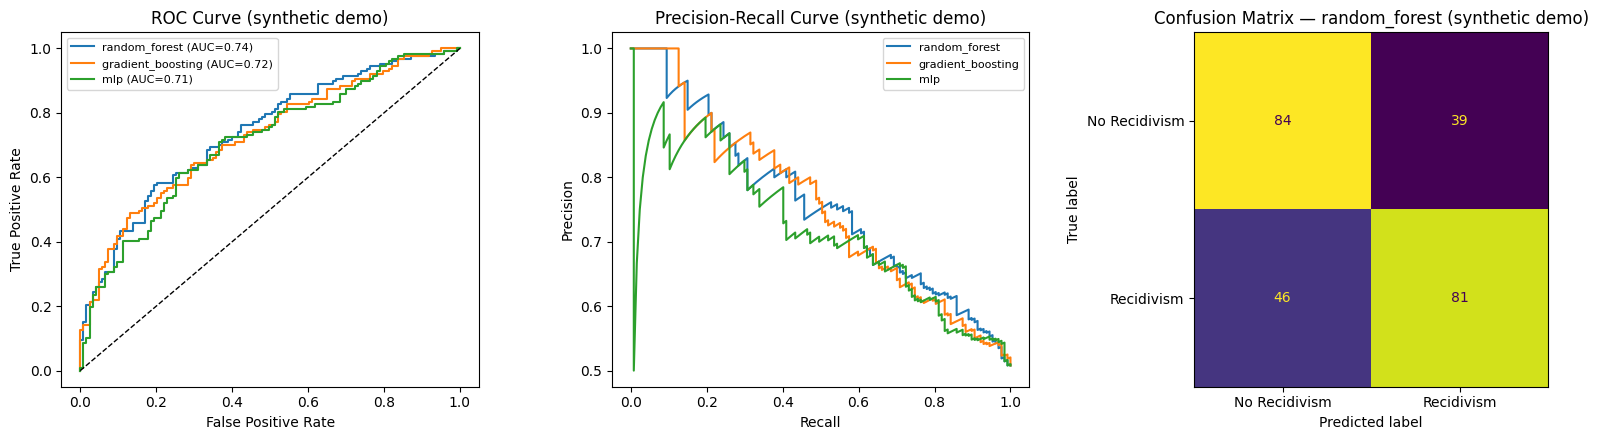

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for name, (fpr, tpr) in roc_data.items():
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={metrics_df.loc[name,'roc_auc']:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve (synthetic demo)")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].legend(fontsize=8)

for name, (prec, rec) in pr_data.items():
    axes[1].plot(rec, prec, label=name)
axes[1].set_title("Precision-Recall Curve (synthetic demo)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend(fontsize=8)

proba_primary = primary_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, (proba_primary >= 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["No Recidivism", "Recidivism"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f"Confusion Matrix — {PRIMARY_MODEL_NAME} (synthetic demo)")

plt.tight_layout()
plt.savefig("outputs/model_performance_plots.png", dpi=110)
plt.show()


## 6. SHAP explainability

### 6a. Global feature importance

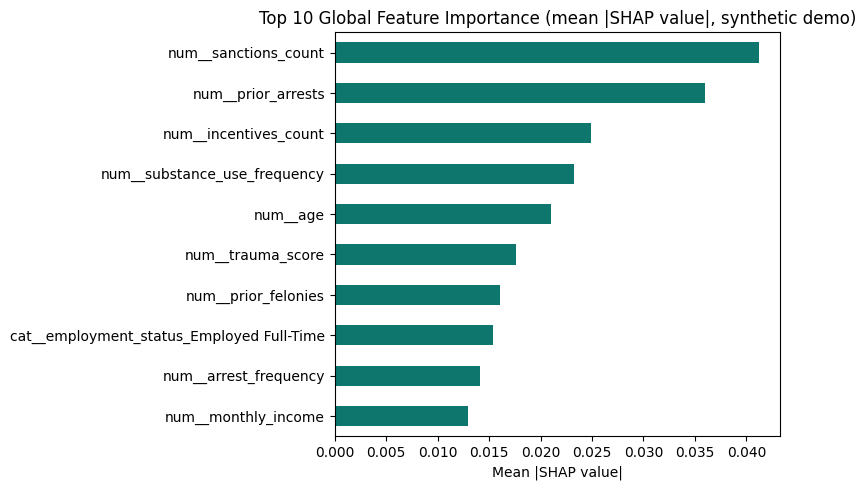

num__sanctions_count                         0.0412
num__prior_arrests                           0.0359
num__incentives_count                        0.0249
num__substance_use_frequency                 0.0232
num__age                                     0.0210
num__trauma_score                            0.0176
num__prior_felonies                          0.0160
cat__employment_status_Employed Full-Time    0.0154
num__arrest_frequency                        0.0141
num__monthly_income                          0.0130
dtype: float64

In [8]:

# Transform test data through the fitted preprocessor for SHAP on the tree model
prep = primary_model.named_steps["preprocess"]
rf = primary_model.named_steps["model"]

X_test_trans = prep.transform(X_test)
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

feature_names_out = list(prep.get_feature_names_out())

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_trans)
# For binary classifiers shap may return a list [class0, class1] or a single array depending on version
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
global_importance = pd.Series(mean_abs_shap, index=feature_names_out).sort_values(ascending=False)
top10 = global_importance.head(10)

plt.figure(figsize=(8, 5))
top10[::-1].plot(kind="barh", color="#0f766e")
plt.title("Top 10 Global Feature Importance (mean |SHAP value|, synthetic demo)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("outputs/global_feature_importance.png", dpi=110)
plt.show()

top10.round(4)


### 6b. Local (participant-specific) explanation

Given one participant, show the top contributing SHAP factors and their direction. Wording follows the paper's guidance: features **contributed to the model's prediction** — they did not *cause* the participant's behavior.

Participant: DC-100780
Model-estimated 3-year recidivism risk: 52%  ->  Risk category: MEDIUM
(This is a model-estimated probability under a prototype model trained on synthetic data — not a fact about this participant's future.)



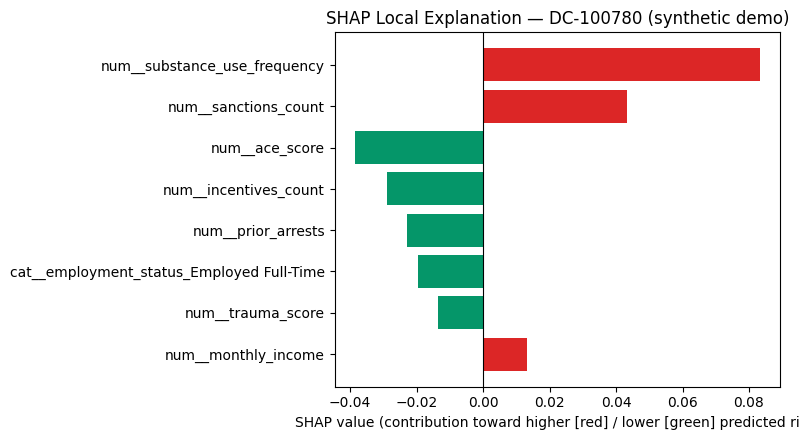

,feature,shap_value,direction
10,num__substance_use_frequency,0.083240,Higher predicted risk
7,num__sanctions_count,0.043276,Higher predicted risk
12,num__ace_score,-0.038527,Lower predicted risk
8,num__incentives_count,-0.028871,Lower predicted risk
3,num__prior_arrests,-0.022896,Lower predicted risk
21,cat__employment_status_Employed Full-Time,-0.019592,Lower predicted risk
11,num__trauma_score,-0.013545,Lower predicted risk
1,num__monthly_income,0.013260,Higher predicted risk


In [9]:

def explain_participant(row_index):
    # row_index: positional index into X_test
    x_row = X_test_trans[row_index:row_index+1]
    proba = rf.predict_proba(x_row)[0, 1]
    sv = shap_values_pos[row_index]
    contrib = pd.DataFrame({
        "feature": feature_names_out,
        "shap_value": sv,
    }).assign(abs_val=lambda d: d.shap_value.abs()).sort_values("abs_val", ascending=False).head(8)
    contrib["direction"] = np.where(contrib.shap_value > 0, "Higher predicted risk", "Lower predicted risk")
    contrib = contrib.drop(columns="abs_val")
    return proba, contrib

def classify_risk(p):
    if p <= RISK_THRESHOLDS["LOW_MAX"]:
        return "LOW"
    elif p <= RISK_THRESHOLDS["MEDIUM_MAX"]:
        return "MEDIUM"
    else:
        return "HIGH"

sample_idx = 3
proba, contrib = explain_participant(sample_idx)
pid = X_test.iloc[sample_idx:sample_idx+1].index
participant_id = df.loc[X_test.index[sample_idx], "participant_id"]

print(f"Participant: {participant_id}")
print(f"Model-estimated 3-year recidivism risk: {proba:.0%}  ->  Risk category: {classify_risk(proba)}")
print("(This is a model-estimated probability under a prototype model trained on synthetic data — not a fact about this participant's future.)\n")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#dc2626" if v > 0 else "#059669" for v in contrib.shap_value]
ax.barh(contrib.feature[::-1], contrib.shap_value[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"SHAP Local Explanation — {participant_id} (synthetic demo)")
ax.set_xlabel("SHAP value (contribution toward higher [red] / lower [green] predicted risk)")
plt.tight_layout()
plt.savefig("outputs/local_shap_explanation.png", dpi=110)
plt.show()

contrib


## 7. Recommendation engine (GenAI pipeline with deterministic fallback)

The prompt design mirrors the paper's SHAP-to-GenAI pipeline: feature definitions + participant values + SHAP values + model output are combined into context. If `OPENAI_API_KEY` is set, that context would be sent to an LLM; otherwise a deterministic rule-based engine (implemented below) produces up to three advisory suggestions from the same inputs, so the system never breaks in the absence of a key.

In [10]:

feature_lookup = {f["feature_name"]: f for f in feature_dictionary}

def build_genai_context(participant_id, proba, contrib, raw_row):
    return {
        "participant_id": participant_id,
        "model_estimated_risk": round(float(proba), 3),
        "risk_category": classify_risk(proba),
        "top_shap_factors": contrib.to_dict(orient="records"),
        "feature_definitions": feature_lookup,
        "raw_values": raw_row.to_dict(),
    }

RULES = {
    "employment_status": {
        "title": "Employment Support",
        "why": "Employment status was among the factors contributing to the model's prediction, and stable employment is associated with lower modeled risk in this dataset.",
        "action": "Consider a referral to a job-readiness or vocational placement program and check in on employment stability at the next review.",
    },
    "substance_use_frequency": {
        "title": "Substance Use Treatment Support",
        "why": "Reported substance use frequency was among the top contributing factors to the model's prediction.",
        "action": "Consider a referral for a substance use assessment by a licensed treatment provider; this system does not diagnose any condition.",
    },
    "sanctions_count": {
        "title": "Program Engagement Support",
        "why": "Sanction history contributed to the model's prediction and may reflect program engagement challenges.",
        "action": "Consider a case-management check-in to review program participation barriers and adjust the engagement plan collaboratively.",
    },
    "trauma_score": {
        "title": "Trauma-Informed Support",
        "why": "The trauma screening score was among the factors contributing to the model's prediction.",
        "action": "Consider a referral to trauma-informed counseling resources for the participant's review and consent.",
    },
    "housing_status": {
        "title": "Housing Stability Support",
        "why": "Housing status contributed to the model's prediction, and housing instability is a commonly cited barrier to program completion.",
        "action": "Consider a referral to housing assistance or transitional housing resources.",
    },
    "program_participation_pct": {
        "title": "Program Engagement Support",
        "why": "Program participation rate was among the factors contributing to the model's prediction.",
        "action": "Consider reviewing attendance barriers (transportation, scheduling) with the participant at the next case review.",
    },
}

def map_transformed_to_base_feature(transformed_name):
    for base in feature_lookup:
        if transformed_name.startswith(f"num__{base}") or transformed_name.startswith(f"cat__{base}"):
            return base
    return None

def generate_recommendations(context, use_genai=False):
    api_key = os.environ.get("OPENAI_API_KEY")
    if use_genai and api_key:
        # Production path: send `context` (json.dumps(context)) as the LLM prompt payload here.
        # Not executed in this offline notebook environment.
        raise NotImplementedError("GenAI call would run here with a configured OPENAI_API_KEY.")
    # --- Deterministic rule-based fallback (active mode in this notebook) ---
    suggestions = []
    seen_titles = set()
    for factor in context["top_shap_factors"]:
        base = map_transformed_to_base_feature(factor["feature"])
        if base in RULES and factor["shap_value"] > 0:
            rule = RULES[base]
            if rule["title"] not in seen_titles:
                suggestions.append(rule)
                seen_titles.add(rule["title"])
        if len(suggestions) == 3:
            break
    if not suggestions:
        suggestions.append({
            "title": "General Case Review",
            "why": "No single factor dominated the prediction for this participant.",
            "action": "Consider a standard case-management review to confirm current needs.",
        })
    return suggestions

engine_mode = "GenAI (LLM)" if os.environ.get("OPENAI_API_KEY") else "Demo recommendation engine (rule-based fallback — no LLM API key configured)"
print("Recommendation engine mode:", engine_mode)

context = build_genai_context(participant_id, proba, contrib, X_test.iloc[sample_idx])
recs = generate_recommendations(context)

for i, r in enumerate(recs, 1):
    print(f"\nINTERVENTION {i}\nTitle: {r['title']}\nWhy this may help: {r['why']}\nSuggested action: {r['action']}")

print("\nDISCLAIMER: AI-generated suggestions are advisory and should be reviewed by qualified professionals. "
      "They are not a substitute for clinical, legal, or judicial judgment.")


Recommendation engine mode: Demo recommendation engine (rule-based fallback — no LLM API key configured)

INTERVENTION 1
Title: Substance Use Treatment Support
Why this may help: Reported substance use frequency was among the top contributing factors to the model's prediction.
Suggested action: Consider a referral for a substance use assessment by a licensed treatment provider; this system does not diagnose any condition.

INTERVENTION 2
Title: Program Engagement Support
Why this may help: Sanction history contributed to the model's prediction and may reflect program engagement challenges.
Suggested action: Consider a case-management check-in to review program participation barriers and adjust the engagement plan collaboratively.

DISCLAIMER: AI-generated suggestions are advisory and should be reviewed by qualified professionals. They are not a substitute for clinical, legal, or judicial judgment.


## 8. Fairness module

Protected attributes were withheld from model training (Section 4). Here they are reattached **only** for a post-hoc subgroup performance comparison — the paper's recommended audit pattern. Disparities, if present in this synthetic run, are reported rather than hidden.

In [11]:

MIN_SUBGROUP_N = 30

def subgroup_metrics(y_true, y_pred, y_proba, group_labels, min_n=MIN_SUBGROUP_N):
    out = []
    for g in sorted(pd.unique(group_labels)):
        mask = (group_labels == g)
        n = mask.sum()
        if n < min_n:
            out.append({"group": g, "n": n, "note": "Insufficient sample size for reliable comparison."})
            continue
        yt, yp, ypr = y_true[mask], y_pred[mask], y_proba[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        out.append({
            "group": g, "n": n,
            "accuracy": round(accuracy_score(yt, yp), 3),
            "precision": round(precision_score(yt, yp, zero_division=0), 3),
            "recall": round(recall_score(yt, yp, zero_division=0), 3),
            "fpr": round(fp / (fp + tn) if (fp + tn) else np.nan, 3),
            "fnr": round(fn / (fn + tp) if (fn + tp) else np.nan, 3),
        })
    return pd.DataFrame(out)

y_test_arr = y_test.values
pred_primary = (proba_primary >= 0.5).astype(int)

fairness_race = subgroup_metrics(y_test_arr, pred_primary, proba_primary, demo_test["race"].values)
fairness_gender = subgroup_metrics(y_test_arr, pred_primary, proba_primary, demo_test["gender"].values)

fairness_race.to_csv("outputs/fairness_by_race_synthetic.csv", index=False)
fairness_gender.to_csv("outputs/fairness_by_gender_synthetic.csv", index=False)

print("Subgroup performance by RACE (synthetic demo data — illustrative only):")
display(fairness_race)
print("\nSubgroup performance by GENDER (synthetic demo data — illustrative only):")
display(fairness_gender)


Subgroup performance by RACE (synthetic demo data — illustrative only):


,group,n,accuracy,precision,recall,fpr,fnr,note
0,Group A,124,0.653,0.632,0.621,0.318,0.379,NaN
1,Group B,48,0.667,0.682,0.625,0.292,0.375,NaN
2,Group C,57,0.667,0.700,0.677,0.346,0.323,NaN
3,Group D,21,NaN,NaN,NaN,NaN,NaN,Insufficient sample size for reliable comparison.



Subgroup performance by GENDER (synthetic demo data — illustrative only):


,group,n,accuracy,precision,recall,fpr,fnr,note
0,Female,87,0.678,0.738,0.646,0.282,0.354,NaN
1,Male,155,0.658,0.653,0.645,0.329,0.355,NaN
2,Nonbinary,8,NaN,NaN,NaN,NaN,NaN,Insufficient sample size for reliable comparison.


## 9. Audit log (demo)

In production this table lives in PostgreSQL (`audit_logs`) and is written on every sensitive action. Here it's simulated as an in-memory log to show the schema and behavior.

In [12]:

audit_log = []

def log_action(user, role, action, participant_id=None, status="success"):
    audit_log.append({
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        "user": user, "role": role, "action": action,
        "participant_id": participant_id, "status": status,
    })

log_action("judge_demo@example.com", "JUDGE", "LOGIN")
log_action("judge_demo@example.com", "JUDGE", "PARTICIPANT_VIEWED", participant_id)
log_action("judge_demo@example.com", "JUDGE", "ASSESSMENT_GENERATED", participant_id)
log_action("judge_demo@example.com", "JUDGE", "SHAP_EXPLANATION_GENERATED", participant_id)
log_action("judge_demo@example.com", "JUDGE", "RECOMMENDATION_GENERATED", participant_id)

audit_df = pd.DataFrame(audit_log)
audit_df.to_csv("outputs/audit_log_demo.csv", index=False)
audit_df


,timestamp,user,role,action,participant_id,status
0,2026-09-25T15:10:04,judge_demo@example.com,JUDGE,LOGIN,NaN,success
1,2026-09-25T15:10:04,judge_demo@example.com,JUDGE,PARTICIPANT_VIEWED,DC-100780,success
2,2026-09-25T15:10:04,judge_demo@example.com,JUDGE,ASSESSMENT_GENERATED,DC-100780,success
3,2026-09-25T15:10:04,judge_demo@example.com,JUDGE,SHAP_EXPLANATION_GENERATED,DC-100780,success
4,2026-09-25T15:10:04,judge_demo@example.com,JUDGE,RECOMMENDATION_GENERATED,DC-100780,success


## 10. Interactive dashboard (inline, ipywidgets)

Select a participant from the synthetic test set and click **Generate Risk Assessment** to see a live, real (not mocked) pipeline run: prediction → SHAP explanation → recommendations, rendered inline exactly as `/participants/:id/assessment` would in a deployed app.

In [13]:

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

test_ids = df.loc[X_test.index, "participant_id"].tolist()
id_to_pos = {pid_: i for i, pid_ in enumerate(test_ids)}

dropdown = widgets.Dropdown(options=test_ids, description="Participant:", layout=widgets.Layout(width="300px"))
run_btn = widgets.Button(description="Generate Risk Assessment", button_style="primary")
out = widgets.Output()

RISK_COLOR = {"LOW": "#059669", "MEDIUM": "#d97706", "HIGH": "#dc2626"}

def on_click(b):
    with out:
        clear_output()
        pos = id_to_pos[dropdown.value]
        steps = ["Preparing participant data...", "Running risk model...",
                 "Generating SHAP explanation...", "Preparing intervention suggestions...", "Assessment ready."]
        for s in steps:
            print(s)

        p, c = explain_participant(pos)
        cat = classify_risk(p)
        pid_ = dropdown.value

        display(HTML(f"""
        <div style="border:1px solid #e2e8f0;border-radius:10px;padding:16px;max-width:640px;font-family:sans-serif">
          <h3 style="margin:0 0 4px 0;color:#0f766e">Participant Risk Assessment — {pid_}</h3>
          <p style="color:#64748b;margin-top:0">Model-estimated three-year recidivism risk (prototype, synthetic data)</p>
          <div style="font-size:34px;font-weight:700;color:{RISK_COLOR[cat]}">{p:.0%} &nbsp; <span style="font-size:18px">{cat}</span></div>
          <p style="font-size:12px;color:#94a3b8">Prototype thresholds — configurable — not clinically validated.</p>
        </div>
        """))

        fig, ax = plt.subplots(figsize=(7, 4))
        colors = ["#dc2626" if v > 0 else "#059669" for v in c.shap_value]
        ax.barh(c.feature[::-1], c.shap_value[::-1], color=colors[::-1])
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(f"Top contributing factors — {pid_}")
        ax.set_xlabel("SHAP value (contribution to model's prediction)")
        plt.tight_layout()
        plt.show()

        ctx = build_genai_context(pid_, p, c, X_test.iloc[pos])
        recs_ = generate_recommendations(ctx)
        html_recs = "".join(
            f"<div style='margin-bottom:8px'><b>{i+1}. {r['title']}</b><br>"
            f"<span style='color:#475569'>Why this may help:</span> {r['why']}<br>"
            f"<span style='color:#475569'>Suggested action:</span> {r['action']}</div>"
            for i, r in enumerate(recs_)
        )
        display(HTML(f"""
        <div style="border:1px solid #e2e8f0;border-radius:10px;padding:16px;max-width:640px;font-family:sans-serif">
          <h4 style="margin-top:0;color:#0f766e">AI-Generated Intervention Suggestions</h4>
          {html_recs}
          <p style="font-size:12px;color:#94a3b8;margin-top:10px">
          AI-generated suggestions are advisory and should be reviewed by qualified professionals.
          They are not a substitute for clinical, legal, or judicial judgment. This is a decision-support
          tool only — it does not make, and cannot make, autonomous decisions about custody, release,
          treatment, or punishment.</p>
        </div>
        """))
        log_action("judge_demo@example.com", "JUDGE", "ASSESSMENT_GENERATED", pid_)

run_btn.on_click(on_click)
display(widgets.HBox([dropdown, run_btn]), out)


Output()

*(Run the cell above, then use the dropdown + button. On first render before clicking, no assessment is shown — this is a live tool, not a screenshot.)*


## 11. Model card

| Field | Value |
|---|---|
| **Purpose** | Decision-support prototype estimating 3-year recidivism risk for drug court participants, with explanations and advisory intervention suggestions. |
| **Intended users** | Authorized drug-court professionals: judges, case managers, treatment providers, probation officers, administrators. |
| **Training data** | Synthetic demo dataset generated in this notebook (1,000 records). **Not** the paper's original dataset. |
| **Features** | 21 features across demographics, socioeconomic status, criminal history, program metrics, and behavioral indicators (see `data/feature_dictionary.json`). |
| **Excluded features** | `race`, `ethnicity` — withheld from training; retained only for fairness auditing. |
| **Target variable** | `recidivism_3yr` (synthetic, illustrative binary label). |
| **Algorithms** | Random Forest (primary), Gradient Boosted Trees, MLP neural network. |
| **Evaluation metrics** | Accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC/PR curves — see Section 5 (synthetic demonstration results only). |
| **Known limitations** | Trained on synthetic data with illustrative, hand-specified correlations; not validated on any real drug-court population; small sample size relative to real deployments; MLP/GBT not hyperparameter-tuned. |
| **Fairness considerations** | Protected attributes excluded from training; post-hoc subgroup recall/FPR/FNR reported in Section 8; disparities are not hidden; small-subgroup results are flagged as unreliable. |
| **Interpretability** | SHAP (TreeExplainer) global and local explanations provided for every prediction. |
| **Human oversight** | All predictions and recommendations are advisory. A qualified professional must review and record the final decision — see the intervention/review workflow described in Section 12. |
| **Out-of-scope uses** | Any autonomous decision about incarceration, release, treatment assignment, or service denial. Any use on real participant data without institutional review, consent processes, and validation. |
| **Synthetic data disclaimer** | The original paper used data from 35,711 participants across 80+ Oklahoma drug courts with 66 variables. This notebook does **not** have access to that dataset and does not claim to reproduce its results. |



## 12. Blueprint for the full production application

Everything above runs today, inside this notebook, on synthetic data. Turning it into the deployed system described in the request — with React, FastAPI, PostgreSQL, JWT auth, Docker, PDF export, and role-based multi-user access — is a separate software engineering project. This section is the concrete spec for that build, derived directly from what was validated in this notebook, so the transition from prototype to product doesn't require re-deriving the ML/XAI/fairness design.

**Project structure**
```
drug-court-dss/
├── frontend/            React + Vite + Tailwind + Recharts + Lucide
│   └── src/{components,pages,layouts,services,hooks,utils}/
├── backend/
│   └── app/{main.py, models/, schemas/, routers/, services/, ml/, xai/, ai/, auth/, database/}
├── data/                 participants.csv (this notebook's synthetic set), feature_dictionary.json
├── models/                random_forest.pkl, gradient_boosting.pkl, mlp.pkl, preprocessing_pipeline.pkl (produced by Sections 3-4)
├── scripts/               generate_demo_data.py, train_models.py, evaluate_models.py (= Sections 3-5, extracted to scripts)
├── docker-compose.yml
└── README.md
```

**Backend routes** (implemented conceptually in Sections 4-9 above; would become FastAPI routers):
`POST /api/auth/login`, `GET /api/auth/me`, `GET/POST/PUT/DELETE /api/participants[/…]`,
`POST /api/assessments`, `POST /api/assessments/{id}/predict`, `GET /api/assessments/{id}/shap`,
`GET /api/model/global-explanations`, `POST /api/assessments/{id}/recommendations`,
`GET/POST /api/participants/{id}/interventions`, `PUT /api/interventions/{id}`,
`GET /api/model/performance`, `GET /api/model/fairness`, `GET /api/model/version`, `GET /api/audit-logs`.

**Database tables**: `users`, `participants`, `participant_assessments`, `risk_predictions`, `shap_explanations`, `intervention_recommendations`, `intervention_plans`, `case_notes`, `audit_logs`, `model_versions` — each mapping directly to an object already produced in this notebook (predictions in Section 5-6, SHAP output in Section 6, recommendations in Section 7, audit rows in Section 9).

**What ports over directly**: `models/*.pkl` + `models/preprocessing_pipeline.pkl` load straight into a FastAPI `predict` endpoint with `joblib.load`; the SHAP explainer and rule-based/GenAI logic in Sections 6-7 becomes `app/xai/` and `app/ai/` services unchanged; the fairness function in Section 8 becomes `GET /api/model/fairness`; `feature_dictionary.json` is served as-is and used to build LLM prompts exactly as in Section 7.

**Still to build for a real deployment**: JWT auth + password hashing + RBAC middleware, PostgreSQL schema + Alembic migrations, the React UI (dashboard, participant table, assessment report, fairness/model-performance/model-card/audit-log pages, PDF export), Docker Compose wiring, and an actual OpenAI API call in place of the `NotImplementedError` stub in Section 7 when `OPENAI_API_KEY` is set.



## Summary of what this notebook actually implements

| # | Requirement | Status in this notebook |
|---|---|---|
| 1 | Synthetic dataset (1,000 participants, correct feature categories) | ✅ Section 3 |
| 2 | Feature dictionary used in GenAI prompt | ✅ Section 2, 7 |
| 3 | Preprocessing (imputation, encoding, scaling), protected attrs excluded | ✅ Section 4 |
| 4 | Three trained models (RF primary, GBT, MLP) saved via joblib | ✅ Section 4 |
| 5 | Evaluation: accuracy/precision/recall/F1/AUC, confusion matrix, ROC, PR — labeled synthetic | ✅ Section 5 |
| 6 | SHAP global importance + local explanation with plots | ✅ Section 6 |
| 7 | Configurable risk thresholds (LOW/MED/HIGH) | ✅ Section 1, 6b |
| 8 | GenAI pipeline design + deterministic no-API-key fallback (max 3 suggestions) | ✅ Section 7 |
| 9 | Fairness subgroup table (recall/FPR/FNR), small-n flagged | ✅ Section 8 |
| 10 | Audit log schema + demo entries | ✅ Section 9 |
| 11 | Interactive live dashboard (select participant → real prediction/SHAP/recs) | ✅ Section 10 |
| 12 | Model card | ✅ Section 11 |
| 13 | React/FastAPI/PostgreSQL/JWT/Docker full-stack app, PDF export, multi-role auth UI | ❌ Not executable inside a notebook — full blueprint given in Section 12 |

**Safety framing used throughout:** every risk number is presented as "model-estimated," every SHAP factor as a "contribution to the prediction" (never a cause), every suggestion as "advisory" requiring professional review, and no cell anywhere computes or displays an automatic accept/deny/incarcerate/release decision.
